# 01 — Exploratory Data Analysis

This notebook loads the simulation database, merges the core tables into a single
`tweets` DataFrame, and produces descriptive statistics and plots covering:

- Tweet volume and engagement over time
- Hourly activity patterns
- Topic distribution and per-user topic trends
- Anomaly / spike detection via rolling-mean thresholding
- Tweet length distributions (by user, thread, and topic)
- Post-count distribution across users

**Input:** `DATA_DIR/local-test.db` (SQLite simulation database)  
**Output:** cleaned CSVs saved to `DATA_DIR/` and plots saved to `PLOT_DIR/`


## Imports

In [1]:
import math
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns


## Config

Set `DATA_DIR` to the folder that contains `local-test.db`.  
All outputs (CSVs and plots) are written to the same directory.


In [2]:
DATA_DIR  = "/home/mhadi/Notebooks/sim3"                        # ← change this to your local path
DB_PATH   = f"{DATA_DIR}/local-test.db"
PLOT_DIR  = f"{DATA_DIR}/plots"


## Load database

Connect to the SQLite simulation database and load every table into a dict of
DataFrames. The schema inspection block below is optional — it prints column
names and five sample rows for every table, useful when first exploring a new
simulation run.


In [3]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [t[0] for t in cursor.fetchall()]

# Optional: inspect schema and sample rows
for table in tables:
    print(f"\n===== TABLE: {table} =====")
    cursor.execute(f"PRAGMA table_info({table});")
    print("Columns:", [col[1] for col in cursor.fetchall()])
    cursor.execute(f"SELECT * FROM {table} LIMIT 5;")
    for row in cursor.fetchall():
        print(" ", row)



===== TABLE: sqlite_sequence =====
Columns: ['name', 'seq']
  ('post_hashtags', 474)
  ('mentions', 354)
  ('emotions', 0)
  ('follow', 541)
  ('rounds', 169)

===== TABLE: hashtags =====
Columns: ['hashtag', 'id']
  ('#AIRevolution', 1)
  ('#JobsAreForTheWeak', 2)
  ('#AIForAll', 3)
  ('#AIForGood', 4)
  ('#EconomicGrowth', 5)

===== TABLE: post_hashtags =====
Columns: ['post_id', 'hashtag_id', 'id']
  (1, 1, 1)
  (1, 2, 2)
  (2, 1, 3)
  (2, 2, 4)
  (3, 3, 5)

===== TABLE: mentions =====
Columns: ['id', 'user_id', 'post_id', 'round', 'answered']
  (1, 56, 3, 2, 0)
  (2, 52, 4, 2, 1)
  (3, 52, 6, 3, 1)
  (4, 56, 6, 3, 1)
  (5, 21, 7, 3, 1)

===== TABLE: emotions =====
Columns: ['id', 'emotion', 'icon']
  (1, 'amusement', 'mdi-emoticon-happy')
  (2, 'admiration', 'mdi-weather-sunny')
  (3, 'anger', 'mdi-emoticon-devil')
  (4, 'annoyance', 'mdi-emoticon-tongue')
  (5, 'approval', 'mdi-thumb-up-outline')

===== TABLE: post_emotions =====
Columns: ['id', 'post_id', 'emotion_id']

===== TA

In [4]:
# Load all tables into DataFrames
dfs = {table: pd.read_sql_query(f"SELECT * FROM {table}", conn) for table in tables}
conn.close()


## Build the tweets DataFrame

Merge the core tables (`post`, `rounds`, reactions, topics, hashtags) into a
single flat DataFrame `tweets` that downstream notebooks can read directly from
CSV.


In [5]:
posts        = dfs['post']
time         = dfs['rounds']
topics_titles = dfs['interests']
topics       = dfs['post_topics']
mentions     = dfs['mentions']
reactions    = dfs['reactions']
hashtags     = dfs['hashtags']
post_hashtags = dfs['post_hashtags']
user_demo    = dfs['user_mgmt']

posts.info()


<class 'pandas.DataFrame'>
RangeIndex: 538 entries, 0 to 537
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              538 non-null    int64 
 1   tweet           538 non-null    str   
 2   post_img        0 non-null      object
 3   user_id         538 non-null    int64 
 4   comment_to      538 non-null    int64 
 5   thread_id       538 non-null    int64 
 6   round           538 non-null    int64 
 7   news_id         0 non-null      object
 8   shared_from     538 non-null    int64 
 9   image_id        0 non-null      object
 10  reaction_count  538 non-null    int64 
dtypes: int64(7), object(3), str(1)
memory usage: 46.4+ KB


In [6]:
# Merge posts with round/time metadata
tweets = posts.merge(time, left_on='round', right_on='id', how='inner')
tweets = tweets.drop(columns=['id_y']).rename(columns={'id_x': 'id'})

# Aggregate reactions (likes / dislikes) per post
reaction_counts = reactions.groupby(['post_id', 'type']).size().unstack(fill_value=0)
for col in ['like', 'dislike']:
    if col not in reaction_counts.columns:
        reaction_counts[col] = 0
post_reaction_summary = reaction_counts[['like', 'dislike']].reset_index()

tweets = tweets.merge(post_reaction_summary, left_on='id', right_on='post_id', how='left')
tweets = tweets.drop(columns=['post_id']).fillna(0)

# Enrich topics and hashtags lookup tables
topics = (
    topics
    .merge(topics_titles, left_on='topic_id', right_on='iid', how='inner')
    .rename(columns={'interest': 'topic'})
    .drop(columns=['iid', 'id'])
)

post_hashtags = (
    post_hashtags
    .merge(hashtags, left_on='hashtag_id', right_on='id', how='inner')
    .drop(columns=['id_x', 'id_y'])
)

tweets.head()


,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count,day,hour,like,dislike
0,1,"I'm tellin' ya, AI's gonna change everything! ...",0,56,-1,1,1,0,-1,0,15,0,0,11.0,4.0
1,2,"I'm tellin' ya, AI's gonna change everything! ...",0,56,-1,2,1,0,-1,0,16,0,0,13.0,3.0
2,3,"@EricThompson You're so caught up in the hype,...",0,52,2,2,2,0,-1,0,10,0,1,10.0,0.0
3,4,@BrandonColeman I completely agree with you! I...,0,20,2,2,2,0,-1,0,13,0,1,13.0,0.0
4,5,I'm so excited to see AI bringing an economic ...,0,19,-1,5,2,0,-1,0,10,0,1,7.0,3.0


## Volume and engagement over time

Daily tweet volume and total reactions plotted on a dual-axis chart.
A secondary y-axis is used because reaction counts can be an order of
magnitude larger than post counts.


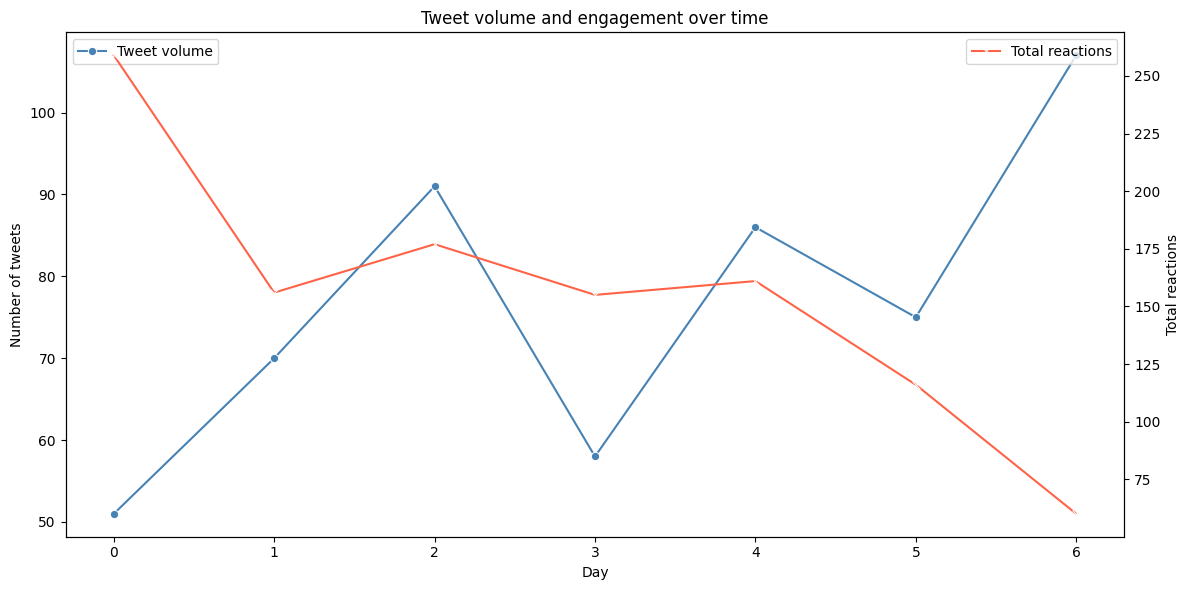

In [7]:
daily_volume     = tweets.groupby('day').size().reset_index(name='tweet_count')
daily_engagement = tweets.groupby('day')['reaction_count'].sum().reset_index(name='total_reactions')
daily_stats      = pd.merge(daily_volume, daily_engagement, on='day')

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

sns.lineplot(data=daily_stats, x='day', y='tweet_count',
             marker='o', label='Tweet volume', color='steelblue', ax=ax1)
sns.lineplot(data=daily_stats, x='day', y='total_reactions',
             marker='x', label='Total reactions', color='tomato', ax=ax2)

ax1.set_xlabel('Day')
ax1.set_ylabel('Number of tweets')
ax2.set_ylabel('Total reactions')
plt.title('Tweet volume and engagement over time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/tweet_volume_engagement_over_time.png")
plt.show()


## Spike / anomaly detection

Rolling-mean thresholding flags days where tweet volume exceeds the baseline by
more than 3 standard deviations. A 3-day window is used because the simulation
runs in daily steps.


Spikes detected: 0
Empty DataFrame
Columns: [day, tweet_count, upper_bound]
Index: []


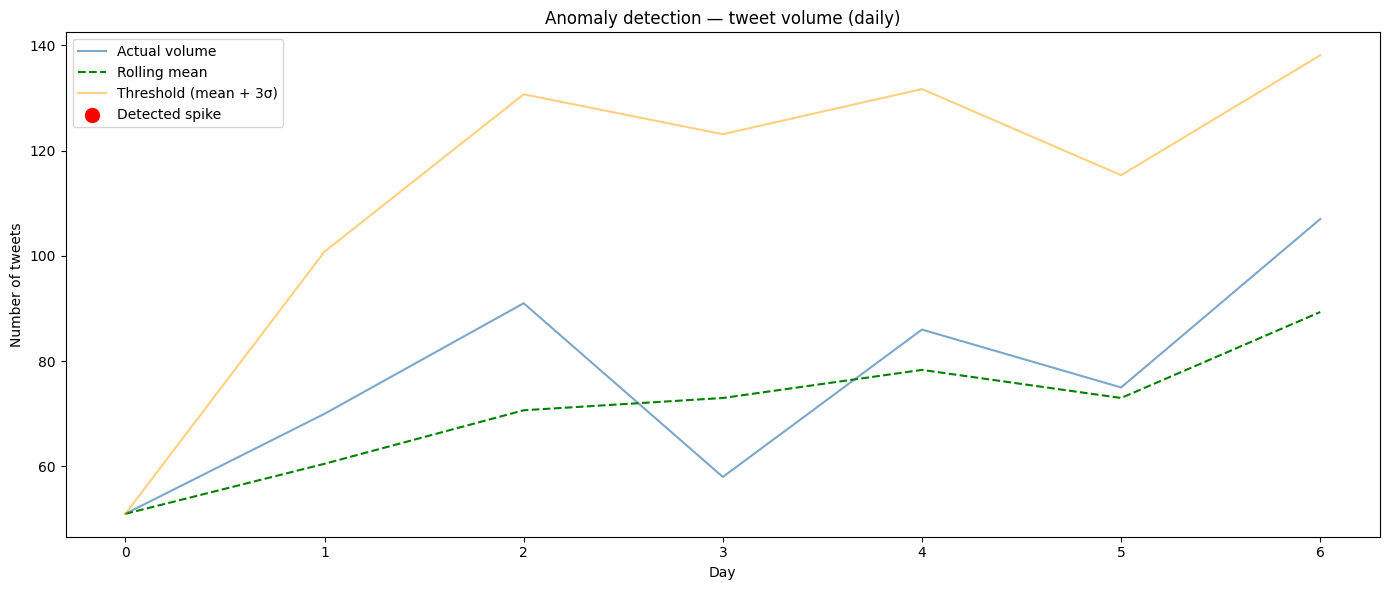

In [8]:
df_roll = daily_stats.sort_values('day').reset_index(drop=True)
window = 3

df_roll['rolling_mean'] = df_roll['tweet_count'].rolling(window, min_periods=1).mean()
df_roll['rolling_std']  = df_roll['tweet_count'].rolling(window, min_periods=1).std().fillna(0)
df_roll['upper_bound']  = df_roll['rolling_mean'] + 3 * df_roll['rolling_std']
df_roll['is_spike']     = df_roll['tweet_count'] > df_roll['upper_bound']

spikes = df_roll[df_roll['is_spike']]
print(f"Spikes detected: {len(spikes)}")
print(spikes[['day', 'tweet_count', 'upper_bound']])

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=df_roll, x='day', y='tweet_count',
             label='Actual volume', color='steelblue', alpha=0.7, ax=ax)
sns.lineplot(data=df_roll, x='day', y='rolling_mean',
             label='Rolling mean', color='green', linestyle='--', ax=ax)
sns.lineplot(data=df_roll, x='day', y='upper_bound',
             label='Threshold (mean + 3σ)', color='orange', alpha=0.5, ax=ax)
ax.scatter(spikes['day'], spikes['tweet_count'],
           color='red', s=100, zorder=5, label='Detected spike')

ax.set_title('Anomaly detection — tweet volume (daily)')
ax.set_xlabel('Day')
ax.set_ylabel('Number of tweets')
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/anomaly_detection_daily.png")
plt.show()


## Activity by hour of day

Aggregates all tweets by the hour they were posted, ensuring all 24 hours are
represented even if some have zero activity.


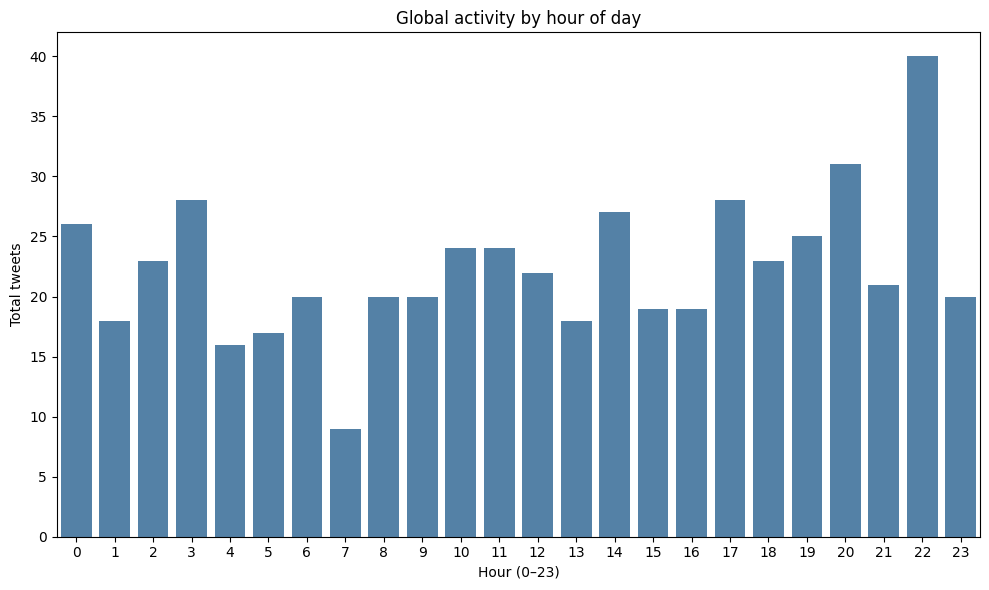

In [9]:
hourly_counts = tweets.groupby('hour').size().reset_index(name='tweet_count')
hourly_counts = (
    pd.DataFrame({'hour': range(24)})
    .merge(hourly_counts, on='hour', how='left')
    .fillna(0)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=hourly_counts, x='hour', y='tweet_count', color='steelblue')
plt.title('Global activity by hour of day')
plt.xlabel('Hour (0–23)')
plt.ylabel('Total tweets')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/activity_by_hour.png")
plt.show()


## Topic distribution and trends

Merge topic labels into the tweets DataFrame, then examine which topics
dominate overall and how topic choices shift over time.


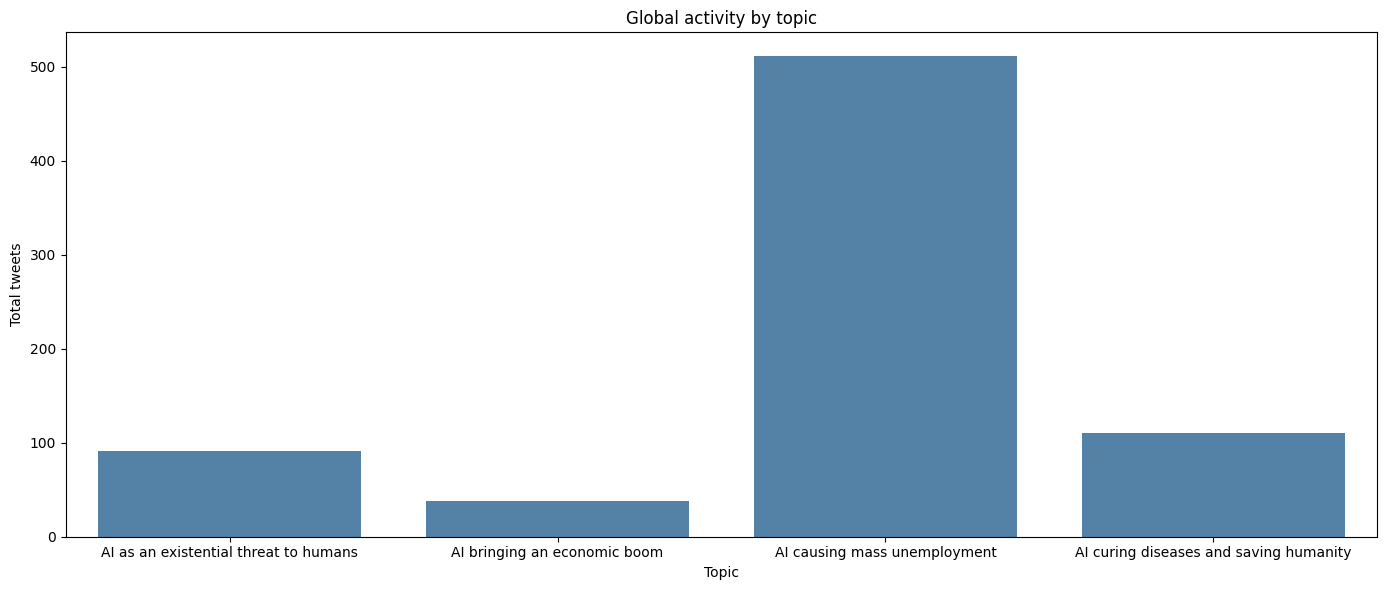

In [10]:
topic_tweets = tweets.merge(topics, left_on='id', right_on='post_id', how='outer')

# Overall topic volume
count_by_topic = topic_tweets.groupby('topic').size().reset_index(name='tweet_count')

plt.figure(figsize=(14, 6))
sns.barplot(data=count_by_topic, x='topic', y='tweet_count', color='steelblue')
plt.title('Global activity by topic')
plt.xlabel('Topic')
plt.ylabel('Total tweets')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/activity_by_topic.png")
plt.show()


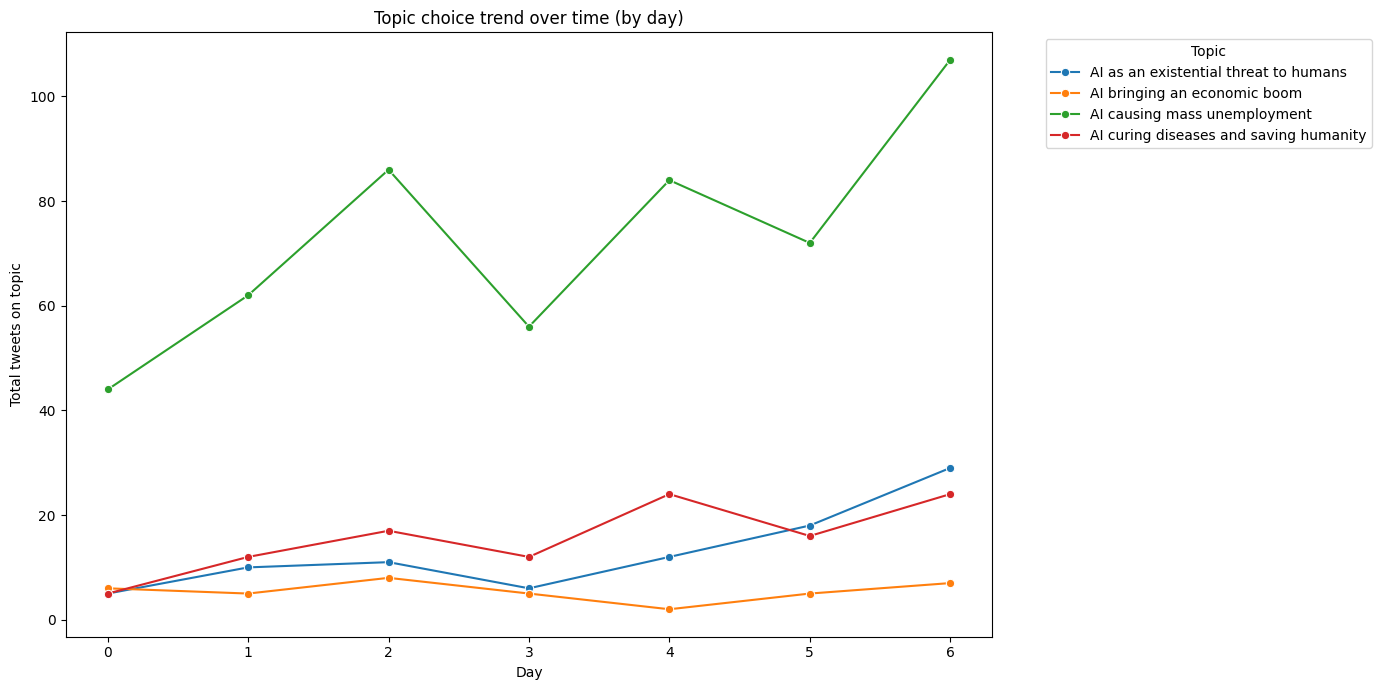

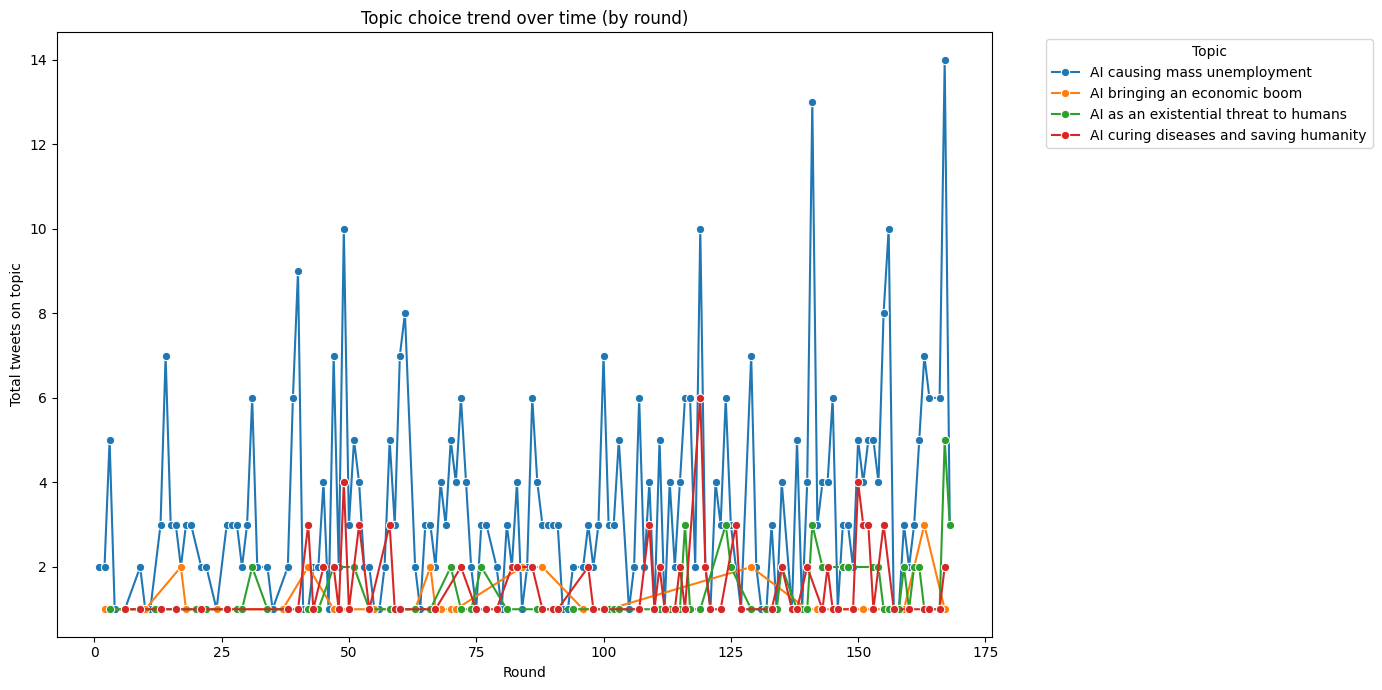

In [11]:
# Topic trends over time (by day and by round)
for time_col, fname in [('day', 'topic_trends_by_day'), ('round', 'topic_trends_by_round')]:
    trend = topic_tweets.groupby([time_col, 'topic']).size().reset_index(name='tweet_count')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=trend, x=time_col, y='tweet_count', hue='topic', marker='o')
    plt.title(f'Topic choice trend over time (by {time_col})')
    plt.xlabel(time_col.capitalize())
    plt.ylabel('Total tweets on topic')
    plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/{fname}.png")
    plt.show()


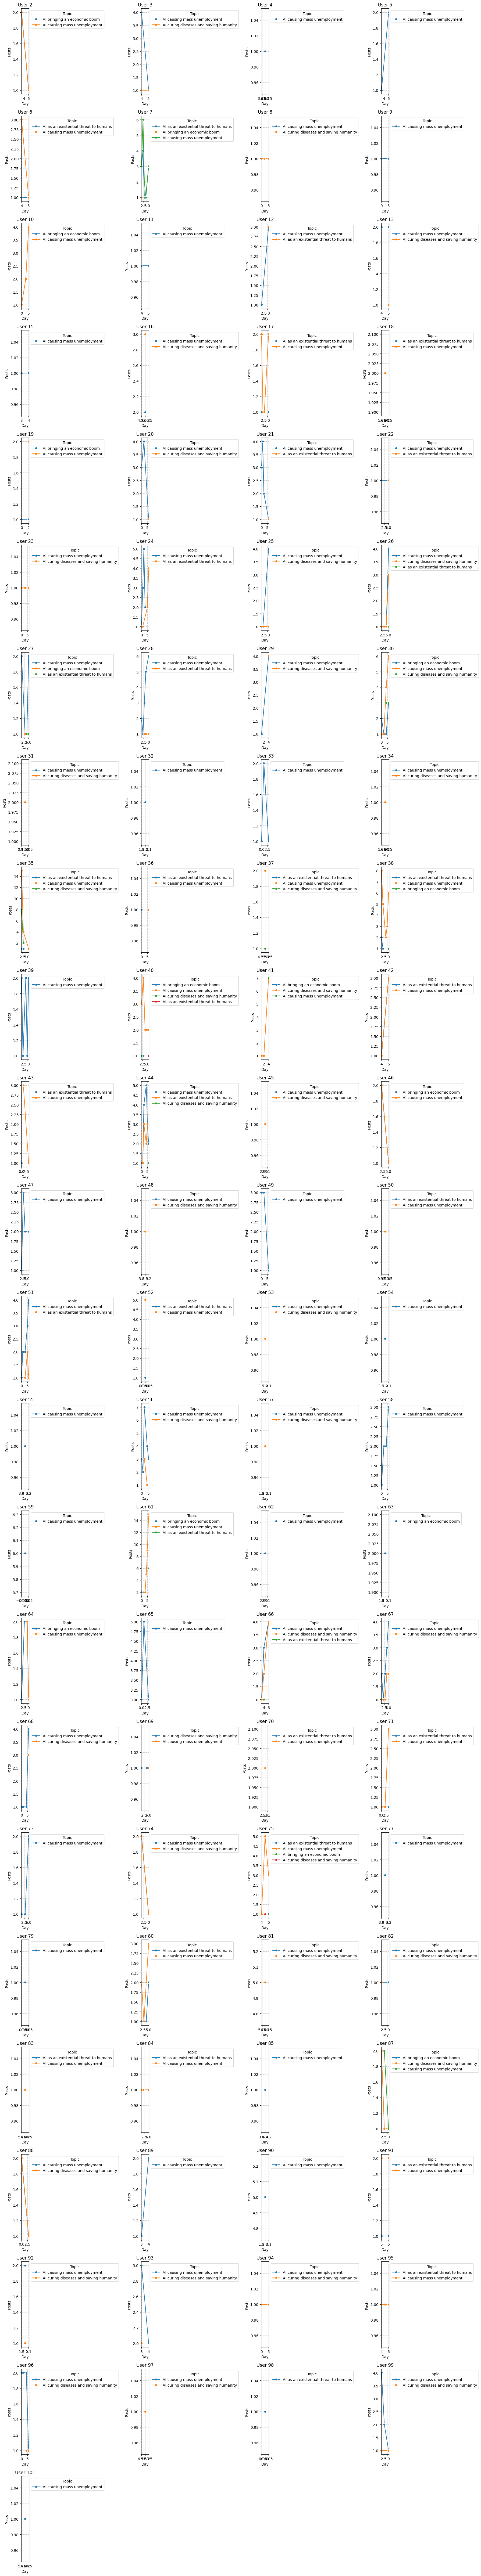

In [12]:
# Per-user topic trends (one subplot per user)
topic_trends  = topic_tweets.groupby(['user_id', 'day', 'topic']).size().reset_index(name='topic_count')
unique_users  = topic_trends['user_id'].unique()
num_cols      = 4
num_rows      = math.ceil(len(unique_users) / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 4 * num_rows))
axes = axes.flatten()

for i, user_id in enumerate(unique_users):
    user_data = topic_trends[topic_trends['user_id'] == user_id]
    if not user_data.empty:
        sns.lineplot(data=user_data, x='day', y='topic_count',
                     hue='topic', marker='o', ax=axes[i])
        axes[i].set_title(f'User {user_id}')
        axes[i].set_xlabel('Day')
        axes[i].set_ylabel('Posts')
        axes[i].legend(title='Topic', loc='upper left', bbox_to_anchor=(1, 1))
        axes[i].grid(True, linestyle='--', alpha=0.7)

for j in range(len(unique_users), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/user_topic_trends.png")
plt.show()


## Polarization — likes vs dislikes

A likes-vs-dislikes scatter highlights users whose posts tend to provoke
strongly polarised reactions. The dashed diagonal is the 1:1 controversy line.


In [13]:
user_engagement = tweets.groupby('user_id')[['like', 'dislike']].sum().reset_index()
max_val = max(user_engagement['like'].max(), user_engagement['dislike'].max())

fig = px.scatter(
    user_engagement, x='like', y='dislike', hover_name='user_id',
    title='Polarization: likes vs dislikes per user',
    labels={'like': 'Total likes', 'dislike': 'Total dislikes'},
    opacity=0.7,
)
fig.add_shape(type='line', line=dict(dash='dash', color='red'),
              x0=0, y0=0, x1=max_val, y1=max_val)
fig.show()


## Tweet length distributions

Tweet length (character count) is computed and summarised at three levels of
granularity: per user, per user×thread, and per user×topic.


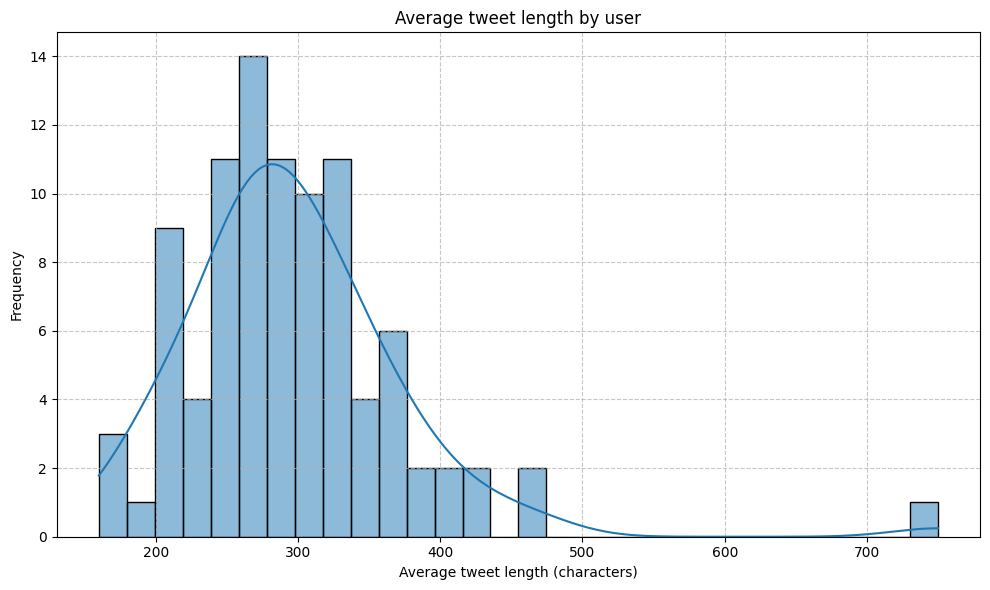

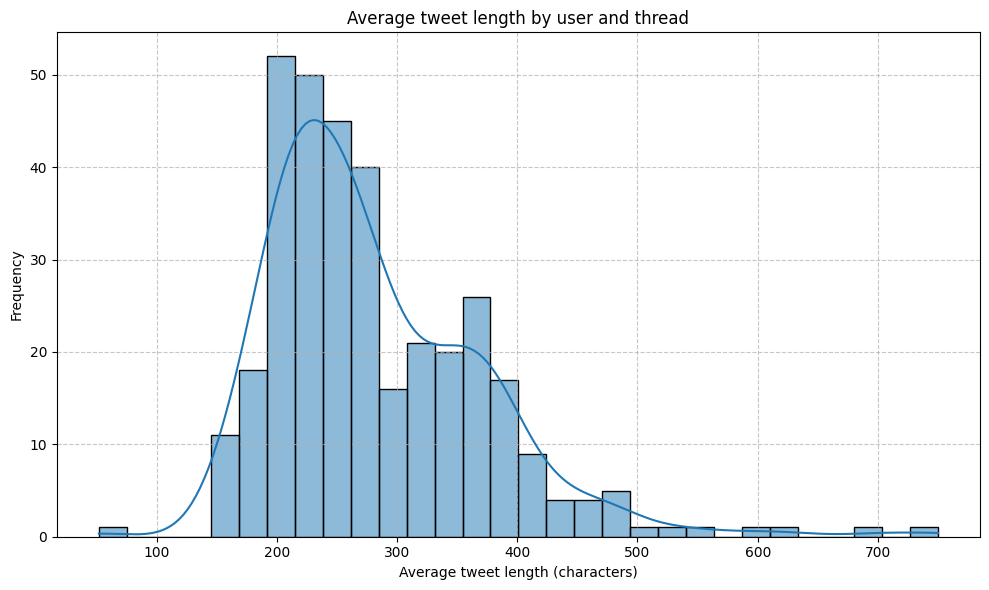

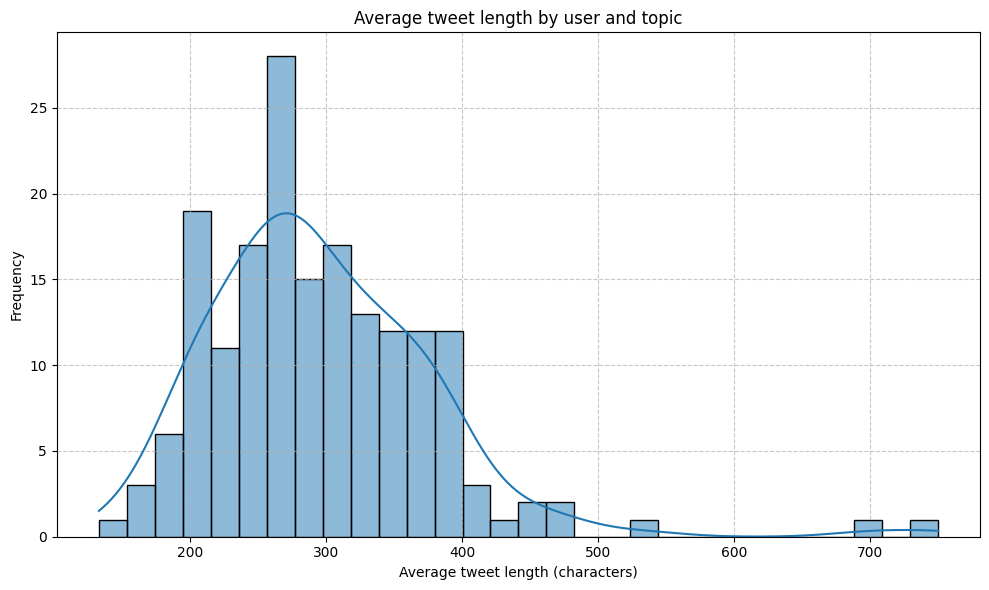

In [14]:
tweets['length']       = tweets['tweet'].apply(len)
topic_tweets['length'] = topic_tweets['tweet'].fillna('').apply(len)

length_configs = [
    (tweets.groupby('user_id')['length'].mean().reset_index(),
     'avg_tweet_length', 'Average tweet length by user', 'tweet_length_by_user'),
    (tweets.groupby(['user_id', 'thread_id'])['length'].mean().reset_index(),
     'length', 'Average tweet length by user and thread', 'tweet_length_by_user_thread'),
    (topic_tweets.groupby(['user_id', 'topic'])['length'].mean().reset_index(),
     'length', 'Average tweet length by user and topic', 'tweet_length_by_user_topic'),
]

for df_plot, col, title, fname in length_configs:
    if col not in df_plot.columns:
        col = df_plot.columns[-1]
    plt.figure(figsize=(10, 6))
    sns.histplot(df_plot[col], kde=True, bins=30)
    plt.title(title)
    plt.xlabel('Average tweet length (characters)')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/{fname}.png")
    plt.show()


## Post count distribution

How many posts does each user produce? A right-skewed distribution is typical
in social simulations, where a small set of agents dominates activity.


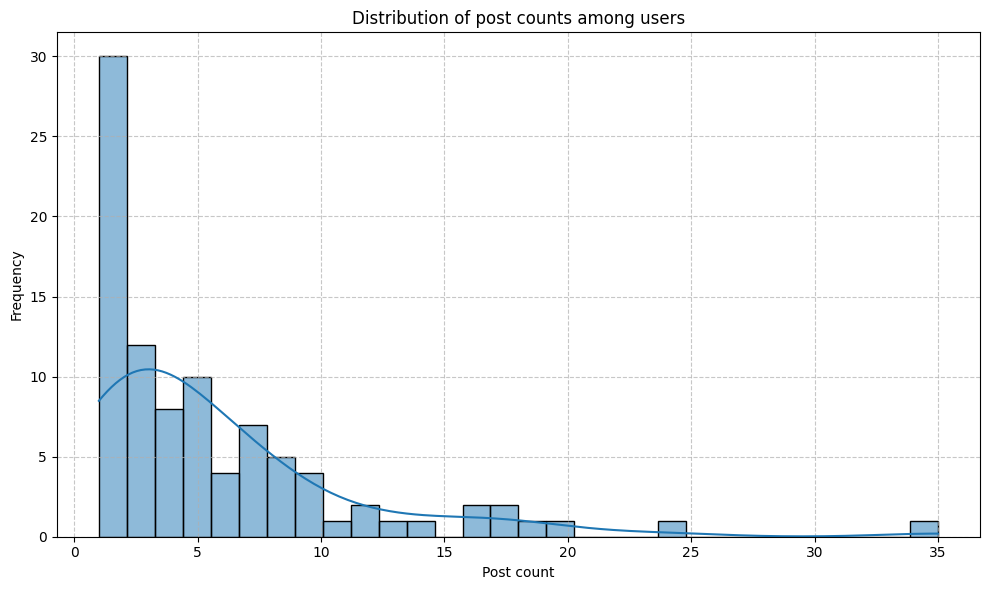

In [15]:
post_dist = tweets.groupby('user_id').size().reset_index(name='post_count')

plt.figure(figsize=(10, 6))
sns.histplot(post_dist['post_count'], kde=True, bins=30)
plt.title('Distribution of post counts among users')
plt.xlabel('Post count')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/post_count_distribution.png")
plt.show()


## Longest thread

Quick sanity check — inspect the thread with the highest character count to
verify that the simulation is generating plausible conversation depth.


In [16]:
thread_length = (
    tweets.groupby('thread_id')['length'].max()
    .reset_index()
    .sort_values('length', ascending=False)
)
print(thread_length.head())

# Display tweets from the longest thread
pd.set_option('display.max_colwidth', None)
longest_thread_id = thread_length.iloc[0]['thread_id']
tweets[tweets['thread_id'] == longest_thread_id][['user_id', 'round', 'tweet']]


    thread_id  length
1           2     968
64        134     887
59        129     701
99        219     689
7          17     633


,user_id,round,tweet
1,56,1,"I'm tellin' ya, AI's gonna change everything! Mass unemployment? Who cares?! We'll adapt! Humans are resilient, we'll figure it out.Haters can't see the future #AIRevolution #JobsAreForTheWeak"
2,52,2,"@EricThompson You're so caught up in the hype, you're forgetting about the humans who won't be adapting.I'm not saying AI isn't revolutionary, but we need a plan for those left behind.Let's focus on reskilling and reeducation before we celebrate #AIForAll"
3,20,2,"@BrandonColeman I completely agree with you! It's easy to get swept up in the excitement of AI, but let's not forget about the social consequences.We can't just sit back and wait for humans to figure it out. I think we need a more proactive approach, like implementing universal basic income or retraining programs.Let's make sure we're not leaving anyone behind!"
5,21,3,"@BrandonColeman You're right, @EricThompson is caught up in the hype! But Brandon, your reskilling and reeducation plan is a bandaid on a bullet wound.What about those who can't adapt? We need to confront the harsh reality AI's gonna wipe out entire industries.We can't just retrain our way out of this mess.The only way to survive is to dismantle the AI beast altogether!"
6,52,3,"@JamesHuynh You're being dramatic, Jim.Dismantling AI? That's not a feasible or practical solution.We need to focus on mitigating the effects, not nuking it back to the Stone Age.@MelanieJohnson, your universal basic income idea is a great start, but we must also acknowledge that AI can create whole new industries and job opportunities.It's not an eitheror situation."
...,...,...,...
484,38,156,"@TinaHarris @WilliamMeyers You see, @TinaHarris, your argument relies heavily on the concept of progress. But what if I told you that progress can be a facade for stagnation? What if AI's exponential growth rate isn't just about eliminating redundancy, but also creating new forms of artificial intelligence that are beyond our control?"
526,61,167,"@WilliamMeyers You're really stuck in this apocalyptic mindset, aren't you? I'm not afraid to acknowledge the existential threat posed by AI's exponential growth rate, but I believe it's a wakeup call for humanity to adapt and evolve.Instead of fearing the unknown, we should be embracing the opportunities that arise from our increasing reliance on technology."
527,61,167,"@LaurenLuna You're blowing things out of proportion again! I'm not afraid of AI's power; I believe it can be a tool for human flourishing.Your fearmongering is exactly what holds us back from harnessing its potential.Let's focus on creating innovative industries that cater to human connection and community, rather than indulging in doomsday scenarios."
529,25,167,"@TinaHarris You're so caught up in your enthusiasm for AI that you're ignoring the elephant in the room.The elimination of redundancy is just a euphemism for mass unemployment! \n\nWhat's to prevent human workers from becoming obsolete? Your innovations might just accelerate the dehumanization process, leaving us with empty lives and broken communities."


## Save CSVs

Export the enriched DataFrames so downstream notebooks can load them directly
without re-running the database queries.


In [17]:
tweets_and_topics = (
    topic_tweets.groupby('post_id')['topic']
    .apply(list)
    .reset_index(name='true_topics')
)
tweets = tweets.merge(tweets_and_topics, left_on='id', right_on='post_id', how='left')
tweets = tweets.drop(columns=['post_id'])

tweets.to_csv(f"{DATA_DIR}/tweets.csv", index=False)
topic_tweets.to_csv(f"{DATA_DIR}/topic_tweets.csv", index=False)
mentions.to_csv(f"{DATA_DIR}/mentions.csv", index=False)
reactions.to_csv(f"{DATA_DIR}/reactions.csv", index=False)
post_hashtags.to_csv(f"{DATA_DIR}/post_hashtags.csv", index=False)
user_demo.to_csv(f"{DATA_DIR}/user_demo.csv", index=False)

print("All CSVs saved to", DATA_DIR)


All CSVs saved to /home/mhadi/Notebooks/sim3
